# Momentum Factor Strategy - Deep Dive Analysis

This notebook provides an exploration of the momentum factor strategy.

## Table of Contents
1. Setup and Data Loading
2. Factor Analysis
3. Performance Metrics
4. Visualizations
5. Deep Dive: Regime Analysis

## 1. Setup and Data Loading

In [1]:
import sys
sys.path.append('../src')
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

from data_manager import DataManager
from factor_engine import MomentumFactor
from performance_analyzer import PerformanceAnalyzer
from visualizer import PerformanceVisualizer
from config import *

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports successful")

✓ Imports successful


In [2]:
# Load data
prices = pd.read_csv('../data/prices_adjusted.csv', index_col=0, parse_dates=True)
signals = pd.read_csv('../data/signals.csv', index_col=0, parse_dates=True)
returns_aligned = pd.read_csv('../data/returns_aligned.csv', index_col=0, parse_dates=True)
print(returns_aligned.tail())
# Load metrics
with open('../results/strategy_metrics.json') as f:
    strategy_metrics = json.load(f)

print(f"Data loaded:")
print(f"  Prices shape: {prices.shape}")
print(f"  Returns shape: {returns_aligned.shape}")
print(f"  Period: {prices.index[0]} to {prices.index[-1]}")

            Strategy  Benchmark
Date                           
2025-01-17  0.009345   0.010040
2025-01-21  0.021570   0.009154
2025-01-22  0.005740   0.005621
2025-01-23  0.004052   0.005458
2025-01-24  0.000606  -0.002919
Data loaded:
  Prices shape: (2531, 464)
  Returns shape: (2531, 2)
  Period: 2015-01-02 00:00:00 to 2025-01-24 00:00:00


## 2. Factor Analysis

### Factor Distribution Over Time

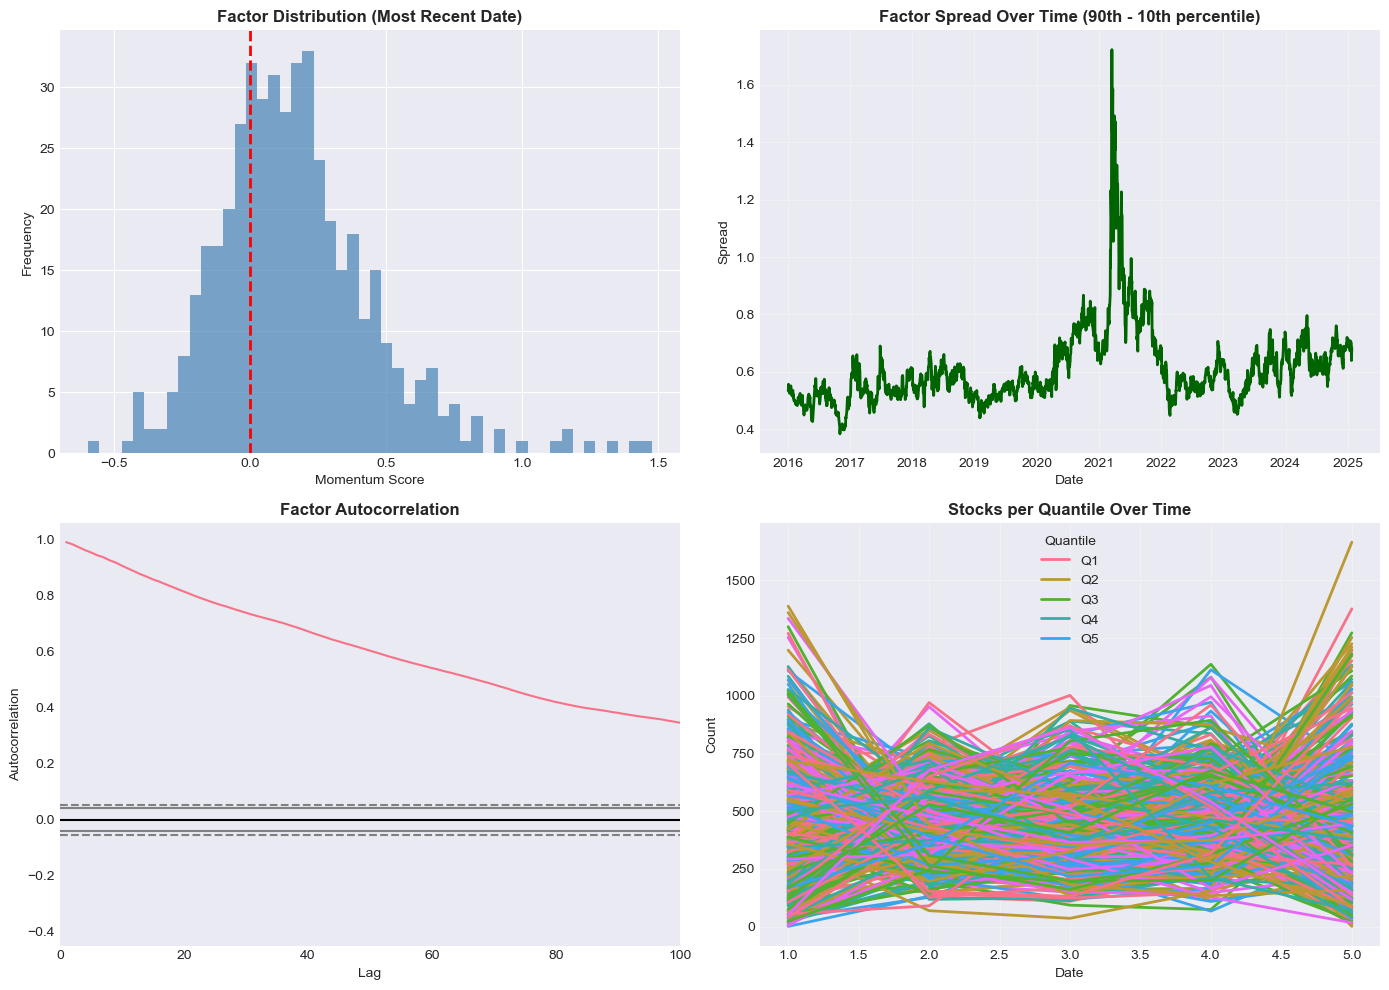


Factor Statistics:
  Mean spread: 60.94%
  Median spread: 57.77%
  Spread volatility: 13.34%


In [3]:
# Load momentum factor
momentum_factor = pd.read_csv('../data/momentum_factor.csv', index_col=0, parse_dates=True)

# Analyze factor distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cross-sectional distribution (last date)
axes[0,0].hist(momentum_factor.iloc[-1].dropna(), bins=50, alpha=0.7, color='steelblue')
axes[0,0].set_title('Factor Distribution (Most Recent Date)', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Momentum Score')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(x=0, color='red', linestyle='--', linewidth=2)

# Factor spread over time (difference between top and bottom decile)
top_decile = momentum_factor.quantile(0.9, axis=1)
bottom_decile = momentum_factor.quantile(0.1, axis=1)
#print(top_decile.shape)
#print(bottom_decile.shape)
spread = top_decile - bottom_decile

axes[0,1].plot(spread.index, spread.values, linewidth=2, color='darkgreen')
axes[0,1].set_title('Factor Spread Over Time (90th - 10th percentile)', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Spread')
axes[0,1].grid(True, alpha=0.3)

# Factor autocorrelation
from pandas.plotting import autocorrelation_plot
# Use median factor value across stocks
median_factor = momentum_factor.median(axis=1)
autocorrelation_plot(median_factor.dropna(), ax=axes[1,0])
axes[1,0].set_title('Factor Autocorrelation', fontsize=12, fontweight='bold')
axes[1,0].set_xlim(0, 100)

# Number of stocks per quantile over time
quantile_counts = signals.apply(lambda x: x.value_counts())
quantile_counts.plot(ax=axes[1,1], linewidth=2)
axes[1,1].set_title('Stocks per Quantile Over Time', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Count')
axes[1,1].legend(title='Quantile', labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFactor Statistics:")
print(f"  Mean spread: {spread.mean():.2%}")
print(f"  Median spread: {spread.median():.2%}")
print(f"  Spread volatility: {spread.std():.2%}")

## 3. Performance Metrics Deep Dive

In [4]:
# Create analyzer
analyzer = PerformanceAnalyzer(
    returns_aligned['Strategy'],
    returns_aligned['Benchmark']
)

# Print detailed summary
analyzer.print_summary()

# Additional metrics
print("\n" + "="*60)
print("ADDITIONAL ANALYSIS")
print("="*60)

# Best and worst months
monthly_returns = analyzer.get_monthly_returns()
print("\nBest Months:")
print(monthly_returns.nlargest(5))

print("\nWorst Months:")
print(monthly_returns.nsmallest(5))

# Yearly performance
yearly_returns = analyzer.get_yearly_returns()
print("\nYearly Returns:")
# print(yearly_returns)


Calculating Performance Metrics...

PERFORMANCE SUMMARY

Return Metrics:
  Total Return:           357.76%
  Annualized Return:       16.36%

Risk Metrics:
  Volatility (Ann.):       21.18%
  Max Drawdown:           -32.77%
  DD Recovery (days):         107

Risk-Adjusted Metrics:
  Sharpe Ratio:              0.68
  Sortino Ratio:             0.81
  Calmar Ratio:              0.50

Other Metrics:
  Win Rate:                50.32%

Benchmark Comparison:
  Correlation:               0.76
  Beta:                      0.91
  Alpha (Ann.):             4.68%
  Information Ratio:         0.34


ADDITIONAL ANALYSIS

Best Months:
Date
2022-10-31    0.141456
2023-11-30    0.139278
2024-02-29    0.114111
2018-08-31    0.109314
2024-11-30    0.106223
Name: Strategy, dtype: float64

Worst Months:
Date
2018-10-31   -0.118032
2022-01-31   -0.086944
2022-06-30   -0.085659
2020-03-31   -0.080785
2018-12-31   -0.070488
Name: Strategy, dtype: float64

Yearly Returns:


## 4. Comprehensive Visualizations

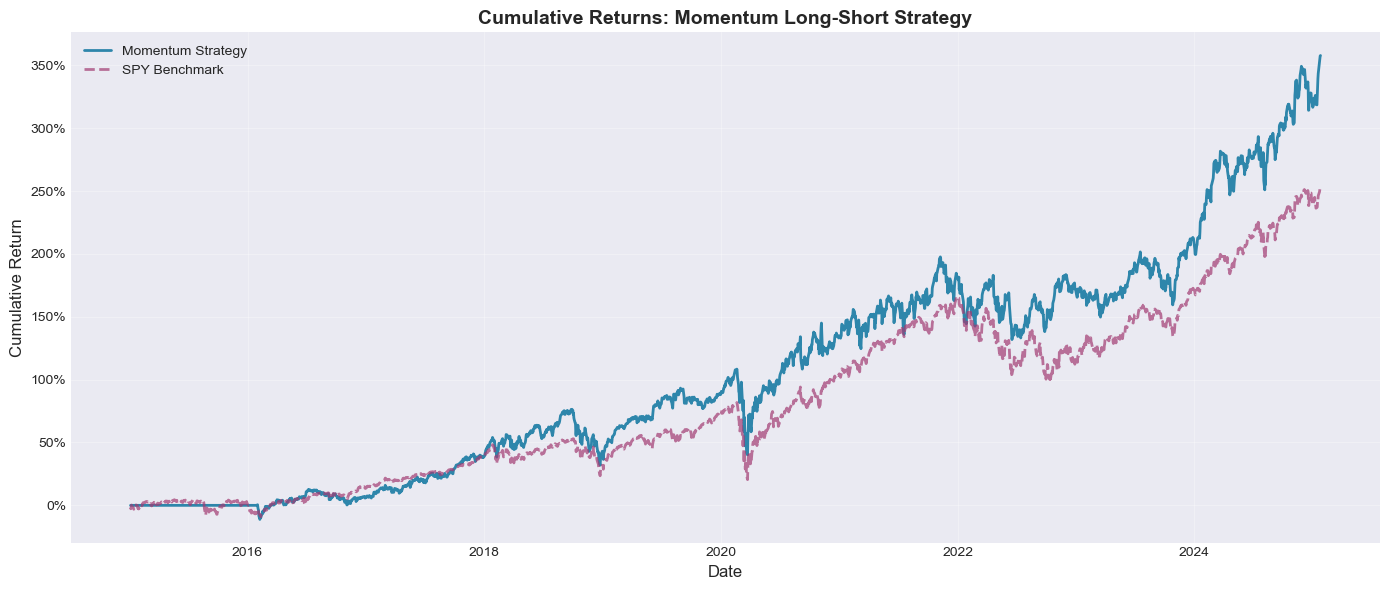

In [5]:
# Create visualizer
viz = PerformanceVisualizer(
    returns_aligned['Strategy'],
    returns_aligned['Benchmark']
)

# Cumulative returns
viz.plot_cumulative_returns(figsize=(14, 6))
plt.show()

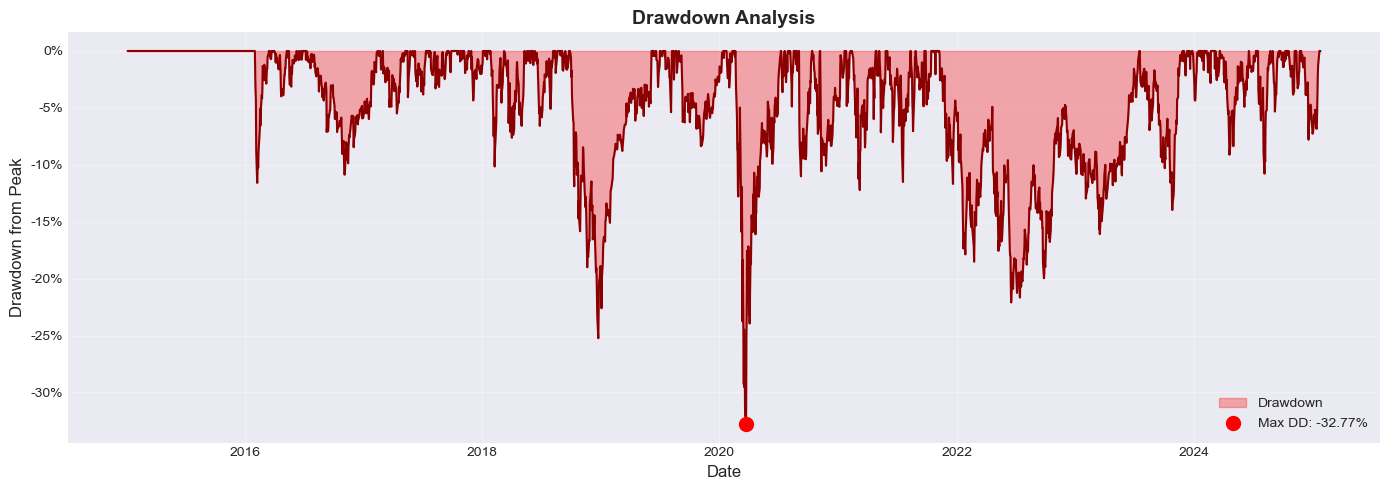

In [6]:
# Drawdown analysis
viz.plot_drawdown(figsize=(14, 5))
plt.show()

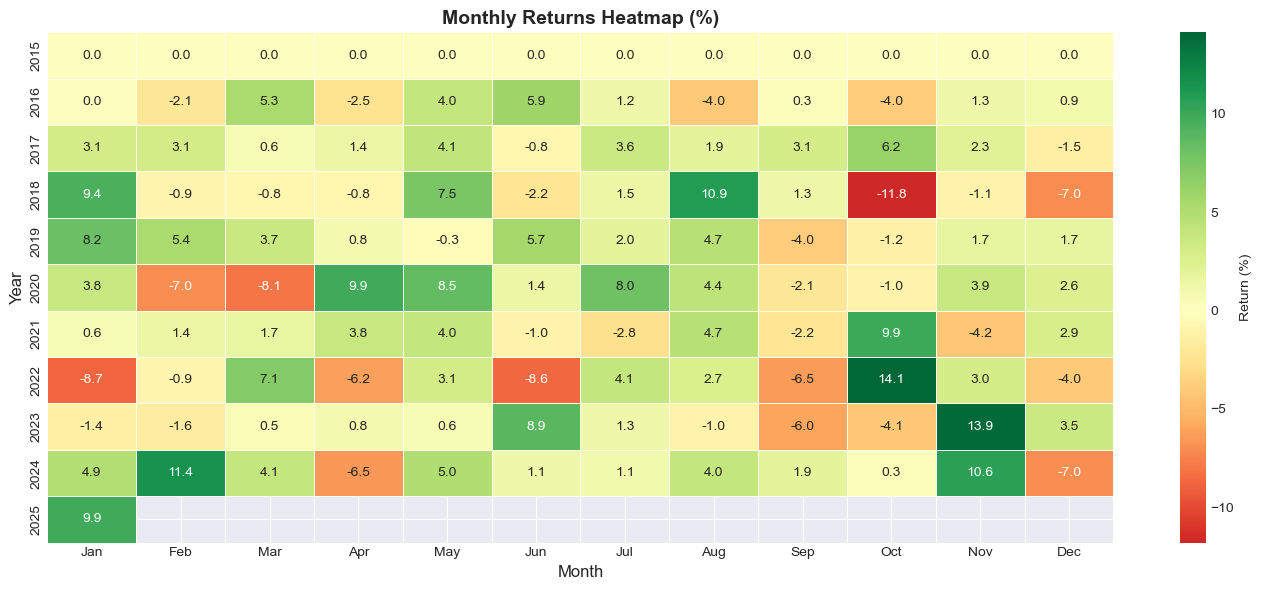

In [7]:
# Monthly returns heatmap
viz.plot_monthly_returns_heatmap(figsize=(14, 6))
plt.show()

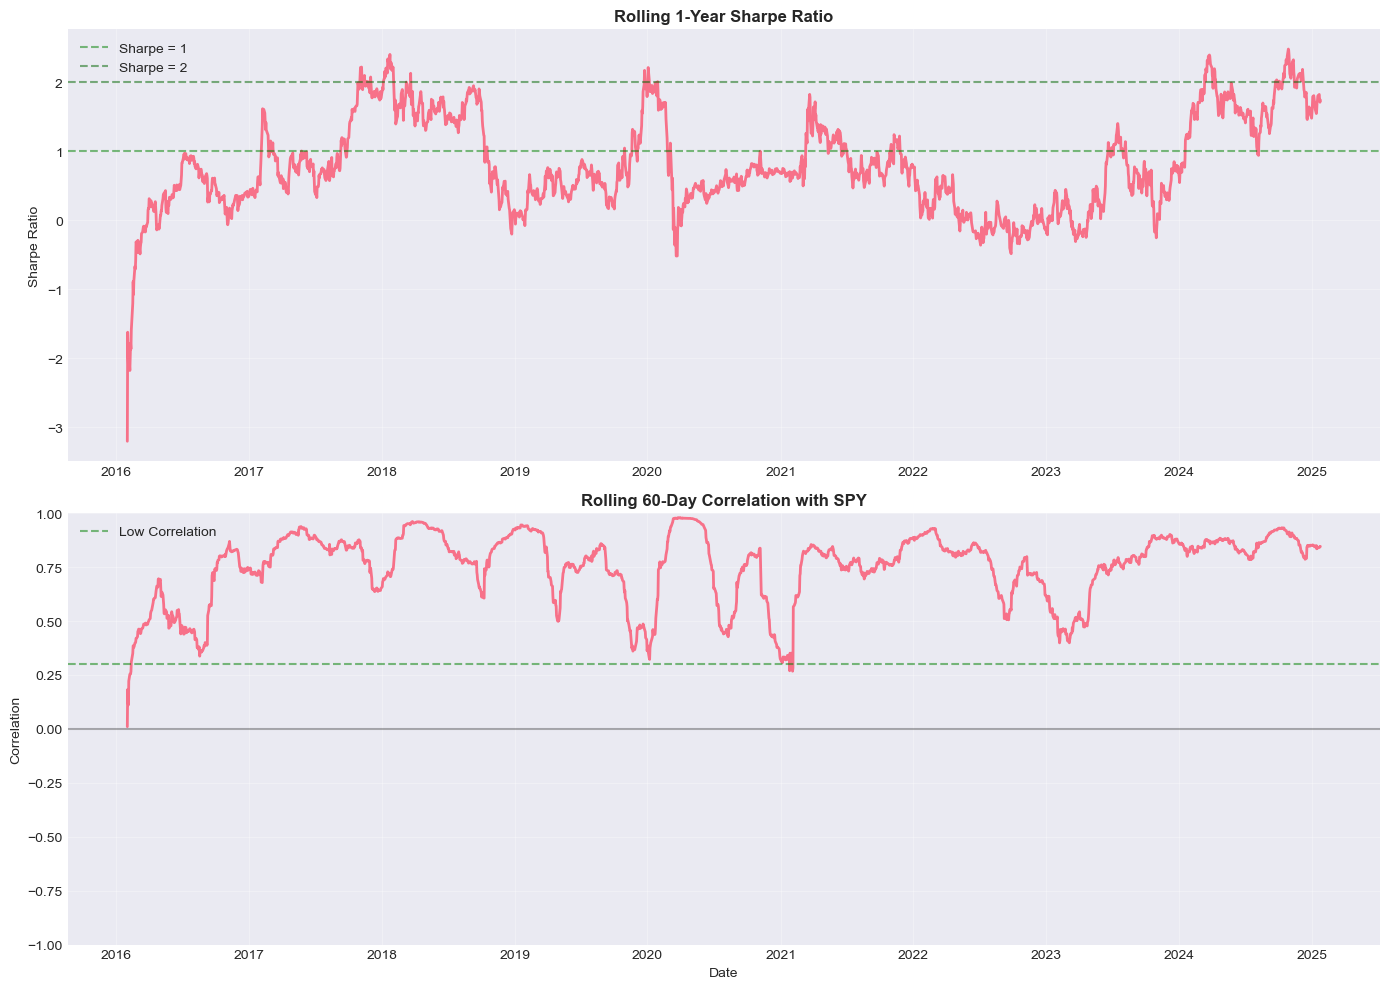

In [9]:
# Rolling metrics
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Rolling Sharpe
rolling_sharpe = analyzer.get_rolling_sharpe(window=252)
axes[0].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=2)
axes[0].axhline(y=1, color='green', linestyle='--', alpha=0.5, label='Sharpe = 1')
axes[0].axhline(y=2, color='darkgreen', linestyle='--', alpha=0.5, label='Sharpe = 2')
axes[0].set_title('Rolling 1-Year Sharpe Ratio', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rolling correlation
aligned_df = pd.concat([returns_aligned['Strategy'], returns_aligned['Benchmark']], axis=1)
rolling_corr = aligned_df['Strategy'].rolling(60).corr(aligned_df['Benchmark'])
axes[1].plot(rolling_corr.index, rolling_corr.values, linewidth=2)
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].axhline(y=0.3, color='green', linestyle='--', alpha=0.5, label='Low Correlation')
axes[1].set_title('Rolling 60-Day Correlation with SPY', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Correlation')
axes[1].set_ylim(-1, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Regime Analysis

Analyze strategy performance in different market conditions


Strategy Performance by Market Regime:
            avg_return  volatility    sharpe   days
Low Vol       0.150584    0.152869  0.985053  816.0
Medium Vol    0.197924    0.197480  1.002247  839.0
High Vol      0.185742    0.275261  0.674783  816.0


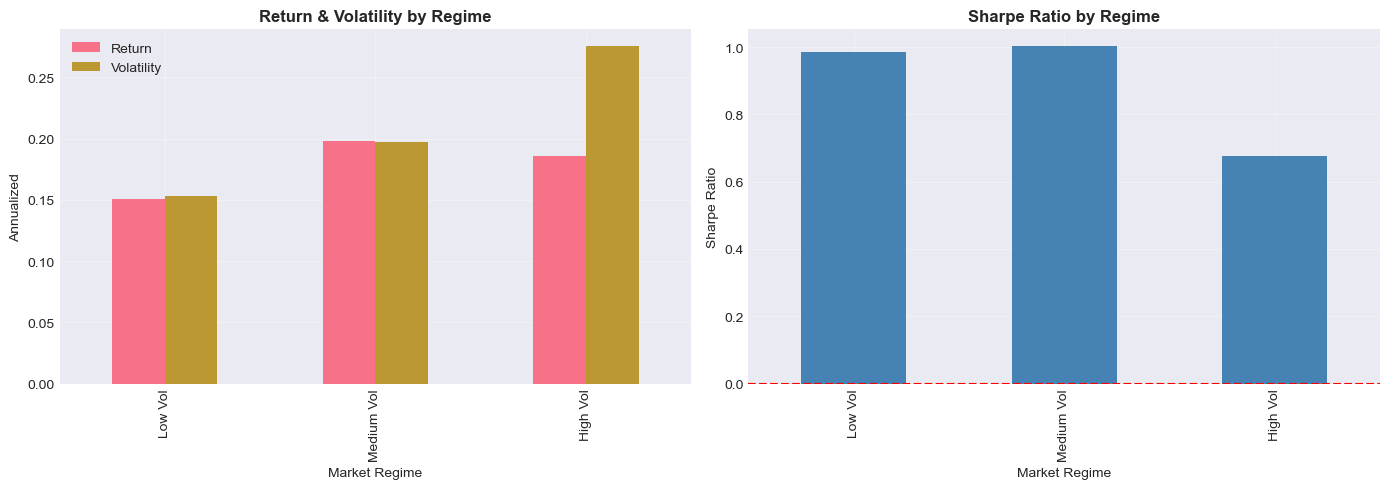

In [ ]:
# Define market regimes based on SPY volatility
spy_returns = returns_aligned['Benchmark']
realized_vol = spy_returns.rolling(60).std() * np.sqrt(252)

# Classify regimes
#vol_quantiles = realized_vol.quantile([0.33, 0.67])
vol_quantiles = realized_vol.quantile([0.33, 0.67])
regimes = pd.cut(realized_vol, 
                bins=[0, vol_quantiles.iloc[0], vol_quantiles.iloc[1], np.inf],
                labels=['Low Vol', 'Medium Vol', 'High Vol'])

# Calculate performance by regime
regime_performance = {}
for regime in ['Low Vol', 'Medium Vol', 'High Vol']:
    mask = (regimes == regime)
    regime_returns = returns_aligned['Strategy'][mask]
    
    regime_performance[regime] = {
        'avg_return': regime_returns.mean() * 252,
        'volatility': regime_returns.std() * np.sqrt(252),
        'sharpe': (regime_returns.mean() * 252) / (regime_returns.std() * np.sqrt(252)),
        'days': len(regime_returns)
    }

# Display results
regime_df = pd.DataFrame(regime_performance).T
print("\nStrategy Performance by Market Regime:")
print(regime_df)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regime_df[['avg_return', 'volatility']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Return & Volatility by Regime', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Market Regime')
axes[0].set_ylabel('Annualized')
axes[0].grid(True, alpha=0.3)
axes[0].legend(['Return', 'Volatility'])

regime_df['sharpe'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Sharpe Ratio by Regime', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Market Regime')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

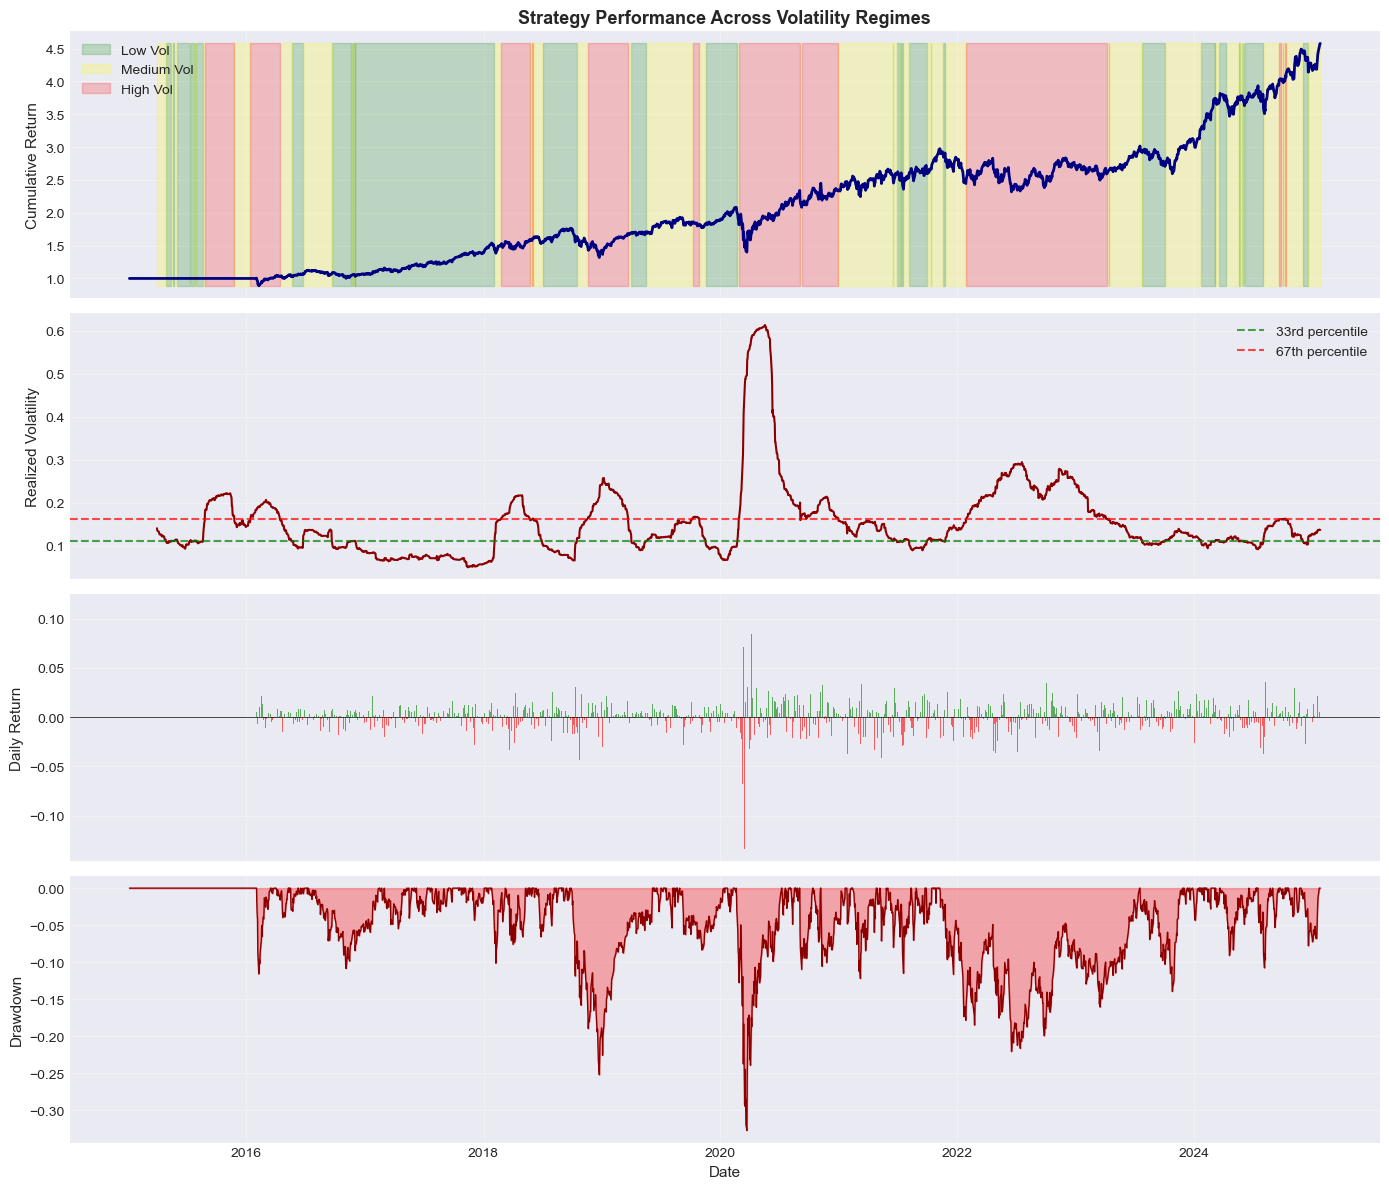

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

portfolio_returns = returns_aligned['Strategy']
cum_returns = (1 + portfolio_returns).cumprod()
axes[0].plot(cum_returns.index, cum_returns.values, linewidth=2, color='navy')
axes[0].set_ylabel('Cumulative Return', fontsize=11)
axes[0].set_title('Strategy Performance Across Volatility Regimes', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

for regime, color in [('Low Vol', 'green'), ('Medium Vol', 'yellow'), ('High Vol', 'red')]:
    regime_mask = (regimes == regime)
    if regime_mask.any():
        axes[0].fill_between(cum_returns.index, 
                            cum_returns.min(), cum_returns.max(),
                            where=regime_mask, alpha=0.2, color=color, label=regime)
axes[0].legend(loc='upper left')

axes[1].plot(realized_vol.index, realized_vol.values, linewidth=1.5, color='darkred')
axes[1].axhline(y=vol_quantiles[0.33], color='green', linestyle='--', alpha=0.7, label='33rd percentile')
axes[1].axhline(y=vol_quantiles[0.67], color='red', linestyle='--', alpha=0.7, label='67th percentile')
axes[1].set_ylabel('Realized Volatility', fontsize=11)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# daily
axes[2].bar(portfolio_returns.index, portfolio_returns.values,width=1, color=portfolio_returns.apply(lambda x: 'green' if x > 0 else 'red'),
           alpha=0.6)
axes[2].axhline(y=0, color='black', linewidth=0.5)
axes[2].set_ylabel('Daily Return', fontsize=11)
axes[2].grid(True, alpha=0.3)


running_max = cum_returns.expanding().max()
drawdown = (cum_returns - running_max) / running_max
axes[3].fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, color='red')
axes[3].plot(drawdown.index, drawdown.values, linewidth=1, color='darkred')
axes[3].set_ylabel('Drawdown', fontsize=11)
axes[3].set_xlabel('Date', fontsize=11)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()